In [ ]:
import torch.nn as nn

class SequentialMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=(128, 64), output_dim=3, dropout=0.2):
        super().__init__() 
        h1, h2 = hidden_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),

            nn.Dropout(p=dropout),

            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(h2, output_dim)
        )

    def forward(self, x):
        # Sequential 컨테이너를 한 번만 호출하면 데이터가 순서대로 흐름
        return self.net(x)

# 3. 실습: 손글씨 숫자 분류하기

## 3-1. 데이터 준비

### 3-1-1. 데이터셋 불러오기, 분할, 표준화

1. sklearn을 통해 손글씨 데디어틑 불러오기
2. 데이터를 학습, 검증, 테스트 용으로 분리
3. 표준화

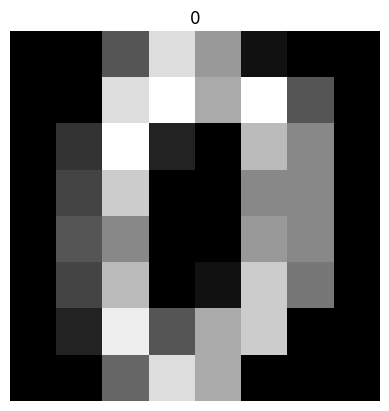

In [15]:
# 1. sklearn을 통해 손글씨 데디어틑 불러오기
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 2. 데이터를 학습, 검증, 테스트 용으로 분리
# load_digits() 함수를 통해 손글씨 데이터셋을 불러옴
    # 손글씨 데이터셋: 8x8 크기의 흑백 이미지로 구성된 숫자(0~9) 이미지 데이터셋
digits = load_digits()


# 손글씨 데이터셋 이미지 출력 해보기
import matplotlib.pyplot as plt

# 첫 번째 이미지 출력
plt.imshow(digits.images[0], cmap='gray')
plt.title(digits.target[0])  # 이미지에 해당하는 숫자 레이블 표시
plt.axis('off')
plt.show()

In [16]:
# 데이터를 학습, (검증, 테스트)용 으로 분리
X_train, X_temp, y_train, y_temp = train_test_split(digits.data, digits.target, test_size=0.3, random_state=42)

# (검증, 테스트) 데이터를 다시 반으로 나눠 각각 검증, 테스트용으로 분리
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 3. 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("학습 데이터 크기:", X_train.shape)
print("학습 데이터 타입:", X_train.dtype)
print("학습 정답 크기:", y_train.shape)
print("학습 정답 타입:", y_train.dtype)

학습 데이터 크기: (1257, 64)
학습 데이터 타입: float64
학습 정답 크기: (1257,)
학습 정답 타입: int64


### 3-1-2. 데이터를 효율적으로 공급하기

1. `TensorDataset`
    - NumPy 배열 데이터를 파이토치 텐서로 변환
    - 입력과 정ㄷ바을 하나의 쌍으로 묶어주는 컨테이너
2. `DataLoader`
    - `TensorDataset`으로 묶인 전체 데이터를 `배치 크기` 만큼 잘라서 모델에 공급
    - 또한, 학습시 데이터를 섞어주는 기능도 제공 (모델이 데이터 순서에 의존하는 것을 방지)

In [17]:
# 4. numpy 배열을 텐서로 변환
from torch.utils.data import TensorDataset, DataLoader
import torch

# 훈련, 검증, 테스트 데이터를 텐서로 변환

# TensorDataset: (입력, 타깃) 쌍을 묶어주는 역할
    # 입력: 실수형(FloatTensor), 타깃: 정수형(LongTensor)으로 변환
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

# DataLoader: 미니배치 단위로 데이터를 불러오는 역할
    # 32개 샘플씩 미니배치로 불러오도록 설정
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

## 3-2. 옵티마이저

### 3-2-1. 옵티마이저

- 대부분의 옵티마이저는 `경사 하강법`의 변형을 사용
- 옵티마이저의 선택과 설정(특히 학습률)은 모델 학습의 성공 여부와 학습 속도에 결정적인 영향을 미침
    - **학습률이 너무 작으면:** 학습이 매우 느려져서 시간이 오래걸림
    - **학습률이 너무 크면:** 손실 값이 발산하거나 최적점을 지나쳐버려 수렴하지 못할 수 있음.

- 그 중, 가장 널리 사용되는 `적응형 학습률` 옵티마이저 중의 하나가 **Adam (Adaptive Moment Estimation)**
    - **적응형 (Adaptive):** 일반적인 SGD(확률적 경사 하강법)와 달리, Adam은 각 파라미터마다 학습률을 다르게 적용하고 조정
    - **모멘텀 (Momentum) 활용:** 이전 기울기의 정보(관성)를 활용하여 최적화 과정에서 발생하는 진동을 줄이고 빠르게 최적점에 도달하도록 도움.
- `torch.optim.Adam`
    - 역전파를 통해 계산된 기울기(`.grad`) 정보를 바탕으로, 모델의 파라미터를 어떻게, 그리고 얼마나 업데이트 할지 결정하는 역할
    - Adam은 **1차 모멘트(이전 기울기의 평균)**와 **2차 모멘트(이전 기울기의 제곱 평균)**를 모두 사용하여 파라미터를 갱신
    - **수동으로 학습률을 조정해야 하는 부담을 줄여줌.**

In [ ]:
# 손실 함수와 옵티마이저 설정
import torch.nn as nn
import torch.optim as optim


# 모델 생성
model = SequentialMLP(input_dim=64, hidden_dim=(128, 64), output_dim=10, dropout=0.2)

# 손실 함수: CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# 옵티마이저: Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)


## 3-3. 학습 및 검증 루프 구현

### 3-3-1. 학습 루프 (train_one_epoch) 구현

- 에포크(Epoch)란 **전체 학습 데이터를 처음부터 끝까지 한 번 모두 사용하는 과정을 의미**
1. `model.train()`: 모델을 학습 모드로 전환 (Dropout 같은 기능 활성화)
2. `DataLoader`에서 미니배치 데이터 가져오기
3. `optimizer.zero_grad()`: 이전 배치의 기울기 정보를 초기화
4. **순전파**
5. **손실 계산**
6. **역전파:** 손실을 기반으로 모든 파라미터의 기울기 계산
7. 파라미터 업데이트: `optimizer.step()`

In [ ]:
# 1. `model.train()`: 모델을 학습 모드로 전환 (Dropout 같은 기능 활성화)
model.train()

for epoch in range(5):  # 5 에폭 동안 학습
    # 2. DataLoader에서 미니배치 데이터 가져오기
    for batch_idx, (data, target) in enumerate(train_loader):

        # 3. 이전 배치의 기울기 정보를 초기화
            # 왜 초기화해야 할까?
            # 기울기는 누적되기 때문에, 매 배치마다 새로운 기울기를 계산하기 위해 초기화해야 함
        optimizer.zero_grad()

        # 4. 순전파
        output = model(data)

        # 5. 손실 계산
        loss = criterion(output, target)

        # 6.역전파 손실을 기반으로 모든 파라미터의 기울기 계산    
            # 체인 룰(연쇄 법칙)을 사용하여 각 레이어의 기울기를 계산
            # 이 과정은 출력층에서 입력층 방향으로 역방향으로 진행
            # 각 레이어의 기울기는 다음 레이어의 기울기와 해당 레이어의 
            # 활성화 함수의 미분값을 곱하여 계산
        loss.backward()

        # 7. 파라미터 업데이트: `optimizer.step()`
        optimizer.step()

        # 8. 10번째 배치마다 손실 출력
        if batch_idx % 10 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')


Epoch 1, Batch 0, Loss: 2.3366
Epoch 1, Batch 10, Loss: 2.1927
Epoch 1, Batch 20, Loss: 1.9925
Epoch 1, Batch 30, Loss: 1.9098
Epoch 2, Batch 0, Loss: 1.4366
Epoch 2, Batch 10, Loss: 1.1178
Epoch 2, Batch 20, Loss: 0.9155
Epoch 2, Batch 30, Loss: 0.8386
Epoch 3, Batch 0, Loss: 0.4773
Epoch 3, Batch 10, Loss: 0.3665
Epoch 3, Batch 20, Loss: 0.4534
Epoch 3, Batch 30, Loss: 0.3471
Epoch 4, Batch 0, Loss: 0.2537
Epoch 4, Batch 10, Loss: 0.1556
Epoch 4, Batch 20, Loss: 0.3400
Epoch 4, Batch 30, Loss: 0.2166
Epoch 5, Batch 0, Loss: 0.2227
Epoch 5, Batch 10, Loss: 0.1626
Epoch 5, Batch 20, Loss: 0.1660
Epoch 5, Batch 30, Loss: 0.1689
